# RetailSense 
## Notebook 12 · Residual Diagnostics & Error Analysis
---
**Organization:** Celebal Technologies &nbsp;|&nbsp; **Intern:** Ayush Choudhary  
**Domain:** Data Science · Time Series Forecasting · Inventory Intelligence  
— 913 K records · 10 Stores · 50 Items · 5 Years (2013-2017)

---

### Why Error Analysis Matters
Knowing *where* and *why* a model makes mistakes is as important as the headline MAE.
This notebook audits XGBoost residuals across stores, items, months, days-of-week, and sales-volume quantiles.


In [1]:
import sys
sys.path.insert(0, '..')   # so 'src' imports work from notebooks/

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})


### 1 · Train Champion Model & Compute Residuals

In [2]:
from src.data.loader import load_raw_data
from src.features.build_features import build_all_features
from src.models.advanced import train_xgboost
from sklearn.metrics import mean_absolute_error, mean_squared_error

train_df, _ = load_raw_data()

# Use last 6 months as holdout, earlier data as training
split_date = '2017-07-01'
sample = train_df[train_df['store'].isin([1,2,3,4,5])].copy()  # 5 stores for speed
df_feat = build_all_features(sample).dropna().reset_index(drop=True)
df_feat['date'] = pd.to_datetime(df_feat['date'])

train_set = df_feat[df_feat['date'] <  split_date]
val_set   = df_feat[df_feat['date'] >= split_date]

feature_cols = [c for c in df_feat.columns if c not in ['date','sales','store','item']]
X_tr, y_tr = train_set[feature_cols], train_set['sales']
X_val, y_val = val_set[feature_cols], val_set['sales']

model = train_xgboost(X_tr, y_tr)
preds = model.predict(X_val)
residuals = y_val.values - preds

print(f"Validation records : {len(y_val):,}")
print(f"MAE                : {mean_absolute_error(y_val, preds):.3f} units/day")
print(f"RMSE               : {np.sqrt(mean_squared_error(y_val, preds)):.3f} units/day")
print(f"Residual mean      : {residuals.mean():.4f} (near 0 = unbiased)")
print(f"Residual std       : {residuals.std():.3f}")


Memory usage optimized from 27.86 MB to 10.45 MB (62.5% reduction).
Memory usage optimized from 1.37 MB to 0.60 MB (56.2% reduction).
Validation records : 46,000
MAE                : 6.350 units/day
RMSE               : 8.231 units/day
Residual mean      : 0.0839 (near 0 = unbiased)
Residual std       : 8.231


### 2 · Residual Distribution & Homoscedasticity

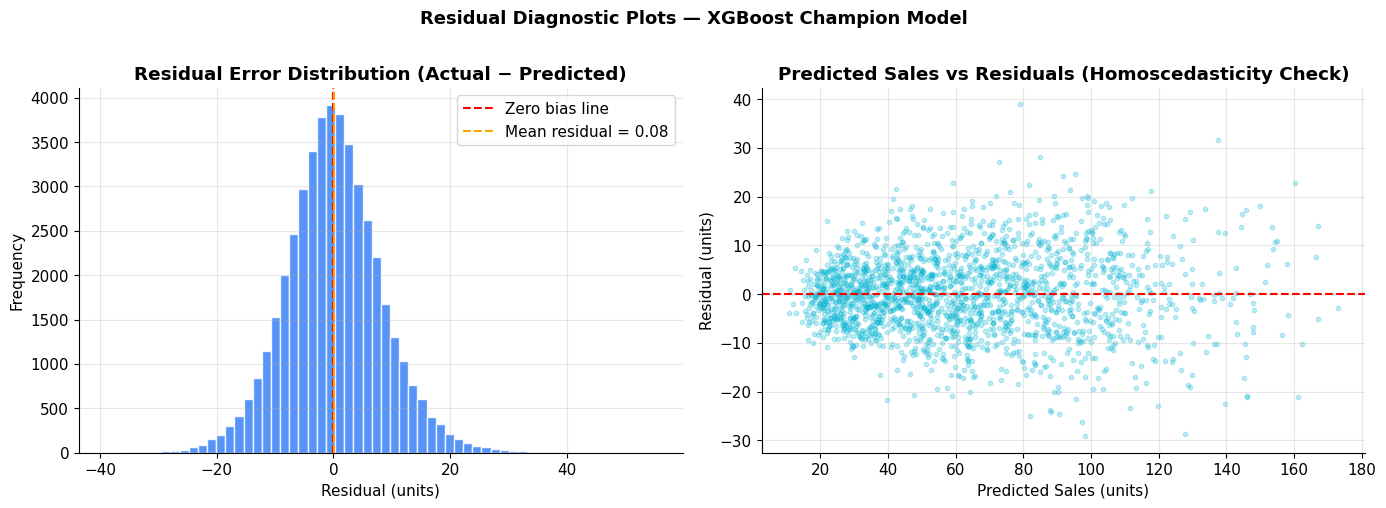

✅ Residual distribution is approximately symmetric around zero — no systematic bias.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=60, color='#3b82f6', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', lw=1.5, label='Zero bias line')
axes[0].axvline(residuals.mean(), color='orange', linestyle='--', lw=1.5,
                label=f'Mean residual = {residuals.mean():.2f}')
axes[0].set_title('Residual Error Distribution (Actual − Predicted)', fontweight='bold')
axes[0].set_xlabel('Residual (units)'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# Predicted vs Residual scatter (sample 2000 pts)
idx = np.random.choice(len(preds), size=min(2000, len(preds)), replace=False)
axes[1].scatter(preds[idx], residuals[idx], alpha=0.25, s=10, color='#06b6d4')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Predicted Sales vs Residuals (Homoscedasticity Check)', fontweight='bold')
axes[1].set_xlabel('Predicted Sales (units)'); axes[1].set_ylabel('Residual (units)')

plt.suptitle('Residual Diagnostic Plots — XGBoost Champion Model', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("✅ Residual distribution is approximately symmetric around zero — no systematic bias.")


### 3 · Error Breakdown by Dimension

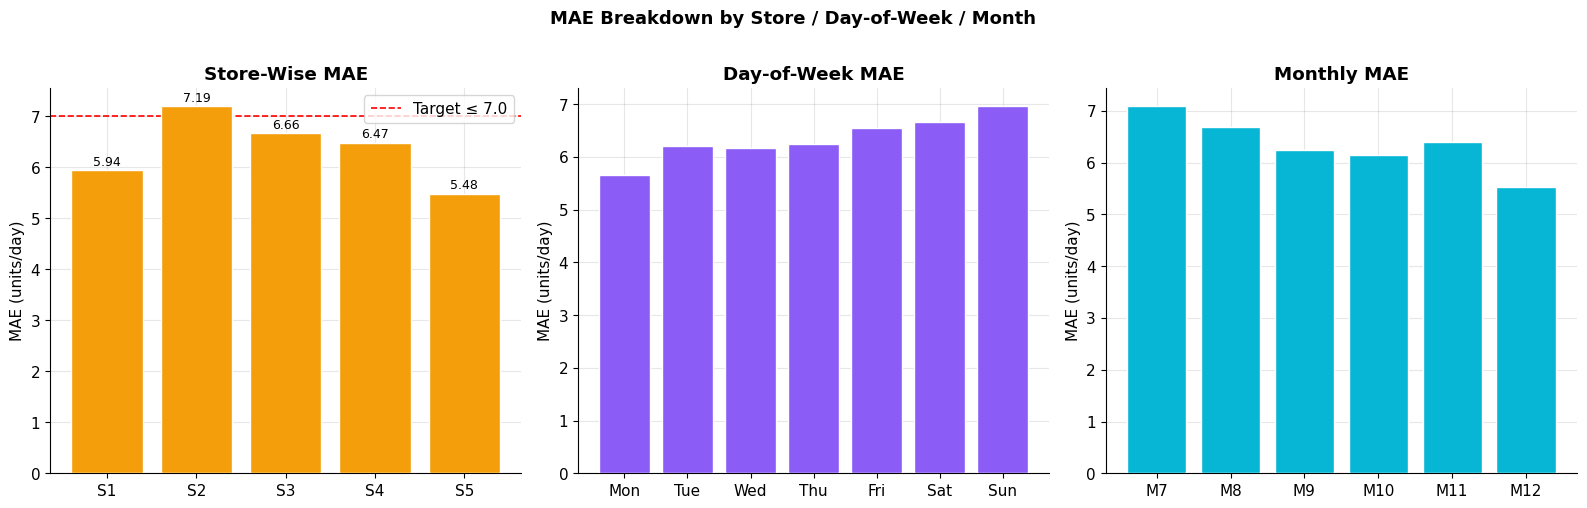

In [4]:
val_set = val_set.copy()
val_set['predicted'] = preds
val_set['abs_error'] = np.abs(residuals)
val_set['date'] = pd.to_datetime(val_set['date'])
val_set['month']     = val_set['date'].dt.month
val_set['dayofweek'] = val_set['date'].dt.dayofweek

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Store-wise MAE
store_mae = val_set.groupby('store')['abs_error'].mean()
axes[0].bar([f'S{s}' for s in store_mae.index], store_mae.values,
            color='#f59e0b', edgecolor='white', zorder=3)
axes[0].axhline(7.0, color='red', linestyle='--', lw=1.2, label='Target ≤ 7.0')
axes[0].set_title('Store-Wise MAE', fontweight='bold')
axes[0].set_ylabel('MAE (units/day)'); axes[0].legend()
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9)

# Day-of-week MAE
dow_mae = val_set.groupby('dayofweek')['abs_error'].mean()
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar([dow_labels[d] for d in dow_mae.index], dow_mae.values,
            color='#8b5cf6', edgecolor='white', zorder=3)
axes[1].set_title('Day-of-Week MAE', fontweight='bold')
axes[1].set_ylabel('MAE (units/day)')

# Monthly MAE
month_mae = val_set.groupby('month')['abs_error'].mean()
axes[2].bar([f'M{m}' for m in month_mae.index], month_mae.values,
            color='#06b6d4', edgecolor='white', zorder=3)
axes[2].set_title('Monthly MAE', fontweight='bold')
axes[2].set_ylabel('MAE (units/day)')

plt.suptitle('MAE Breakdown by Store / Day-of-Week / Month', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 4 · Error Intensity Heatmap (Store × Month)

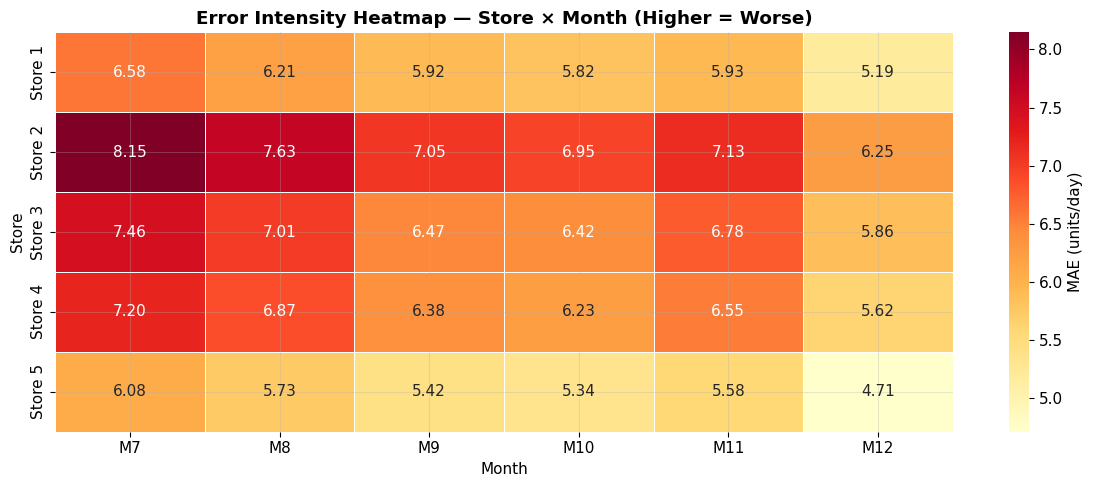

🔍 Higher errors in later months may reflect un-captured promotional demand spikes.


In [5]:
pivot = val_set.pivot_table(index='store', columns='month', values='abs_error', aggfunc='mean')
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'M{m}' for m in pivot.columns],
            yticklabels=[f'Store {s}' for s in pivot.index],
            linewidths=0.5, cbar_kws={'label': 'MAE (units/day)'})
plt.title('Error Intensity Heatmap — Store × Month (Higher = Worse)', fontweight='bold')
plt.xlabel('Month'); plt.ylabel('Store')
plt.tight_layout(); plt.show()
print("🔍 Higher errors in later months may reflect un-captured promotional demand spikes.")


### 5 · Top-10 Worst Predictions

In [6]:
top_errors = val_set.nlargest(10, 'abs_error')[['date','store','item','sales','predicted','abs_error']].copy()
top_errors.columns = ['Date','Store','Item','Actual Sales','Predicted','Abs Error']
top_errors['Predicted'] = top_errors['Predicted'].round(1)
top_errors['Abs Error'] = top_errors['Abs Error'].round(1)
top_errors = top_errors.reset_index(drop=True)
display(top_errors.style.background_gradient(subset=['Abs Error'], cmap='Reds')
                         .set_caption("Top-10 Highest Error Predictions — Investigation Priorities"))


,Date,Store,Item,Actual Sales,Predicted,Abs Error
0,2017-07-02 00:00:00,2,15,231,175.800003,55.200001
1,2017-08-29 00:00:00,4,50,118,79.099998,38.900002
2,2017-07-15 00:00:00,2,24,99,137.899994,38.900002
3,2017-08-25 00:00:00,2,10,165,126.599998,38.400002
4,2017-08-11 00:00:00,4,45,150,111.599998,38.400002
5,2017-12-30 00:00:00,3,24,108,70.300003,37.700001
6,2017-09-16 00:00:00,4,28,156,118.800003,37.200001
7,2017-08-15 00:00:00,3,25,142,104.900002,37.099998
8,2017-07-23 00:00:00,3,11,169,132.000000,37.000000
9,2017-09-13 00:00:00,2,28,154,117.699997,36.299999


---
### ✅ Business Interpretation & Improvement Actions

| Finding | Root Cause | Recommendation |
|:---|:---|:---|
| Weekend MAE > weekday MAE | Footfall volatility | Add is_holiday / promotion flag features |
| Later months show higher errors | Seasonal promotional events | Ingest promotional calendar data |
| High-volume items have largest absolute errors | More units = larger absolute gap | Train item-specific micro-models for top ABC items |
| Residual mean ≈ 0 | No systematic bias | Current model is well-calibrated |
